In [ ]:
# Восклицательный знак ! означает, что обращаемся
# не к Python, а к командной строке Colab (терминалу)
# Ключ -q (quiet) отключает вывод лишних сообщений

!pip install matplotlib seaborn plotly pandas numpy -q

In [ ]:
import pandas as pd                 # Таблицы
import numpy as np                  # Массивы и случайные числа
import matplotlib.pyplot as plt     # Базовая визуализация
import seaborn as sns               # Красивая надстройка над Matplotlib
import plotly.express as px         # Интерактивные графики
import plotly.io as pio             # Настройка отображения Plotly

# sns.set_theme() — устанавливает стиль для всех графиков
# darkgrid — тёмная сетка, более профессиональный вид

sns.set_theme(style="darkgrid")
pio.renderers.default = 'colab'
print("Библиотеки загружены и готовы к работе!")

Библиотеки загружены и готовы к работе!


In [ ]:
# создаём синтетические данные, чтобы потренироваться
# без загрузки реальных файлов

np.random.seed(42)  # Фиксируем случайность, чтобы каждый раз получать одинаковые числа

N = 2000  # Количество клиентов

# Списки, из которых будем выбирать случайные значения
cities = ['Минск', 'Воложин', 'Молодечно', 'Гродно', 'Ивье']
names = ['Иван', 'Ольга', 'Дмитрий', 'Екатерина', 'Сергей', 'Анна', 'Алексей', 'Мария']


# pd.DataFrame() — создаём таблицу из словаря. Каждый
# ключ словаря становится названием колонки, а значение   — списком данных для этой колонки

df = pd.DataFrame({
    'client_id': range(1001, 1001 + N),          # ID клиентов от 1001 до 1001+N-1
    'name': np.random.choice(names, N),           # Случайные имена
    'city': np.random.choice(cities, N),          # Случайные города
    'age': np.random.randint(21, 70, N),          # Возраст от 21 до 69 (randint идёт до 70 не включительно)
    'income': np.random.normal(50000, 20000, N).astype(int),  # Доход из нормального распределения (среднее 50 000, разброс 20 000)
    'loan_amount': np.random.normal(200000, 80000, N).astype(int),  # Сумма кредита
    'credit_score': np.random.normal(650, 100, N).astype(int),  # Кредитный скоринг
    'default': np.random.choice([0, 1], N, p=[0.9, 0.1])  # 0 — платит, 1 — дефолт, вероятность 10%
})


# Добавляем несколько "аномалий" для наглядности:
# .loc[] — обращение к строке по её номеру (индексу)
# Первая строка (индекс 0) получит доход 500000
# Вторая строка (индекс 1) получит кредит 1000000
# Третья строка (индекс 2) получит возраст 18 лет

df.loc[0, 'income'] = 500000
df.loc[1, 'loan_amount'] = 1000000
df.loc[2, 'age'] = 18

# Убираем возможные отрицательные значения (метод .clip(lower=0) заменяет всё, что <0, на 0)
df['income'] = df['income'].clip(lower=0)
df['loan_amount'] = df['loan_amount'].clip(lower=0)

print(f"Датасет: {df.shape[0]} строк, {df.shape[1]} колонок")
df.head()

Датасет: 2000 строк, 8 колонок


,client_id,name,city,age,income,loan_amount,credit_score,default
0,1001,Алексей,Гродно,56,500000,224515,682,0
1,1002,Екатерина,Молодечно,28,48287,1000000,755,0
2,1003,Сергей,Ивье,18,80152,144570,605,0
3,1004,Алексей,Минск,52,36156,195643,717,0
4,1005,Дмитрий,Ивье,34,76160,165023,371,0


In [ ]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=df)

https://docs.google.com/spreadsheets/d/1ScWu9-7UP_hE4NSqVR3pUcDiqNHKdVq63OsrGgeQHN4/edit#gid=0


# Линейный график (Line Plot)
## Зачем нужен в банке:
- Смотреть, как меняется количество заявок на кредит изо дня в день
- Отслеживать просрочки во времени
- Показывать тренды руководству

## Что будем строить:
30-дневный ряд "ежедневного количества заявок" и добавим скользящее среднее, чтобы сгладить шум.

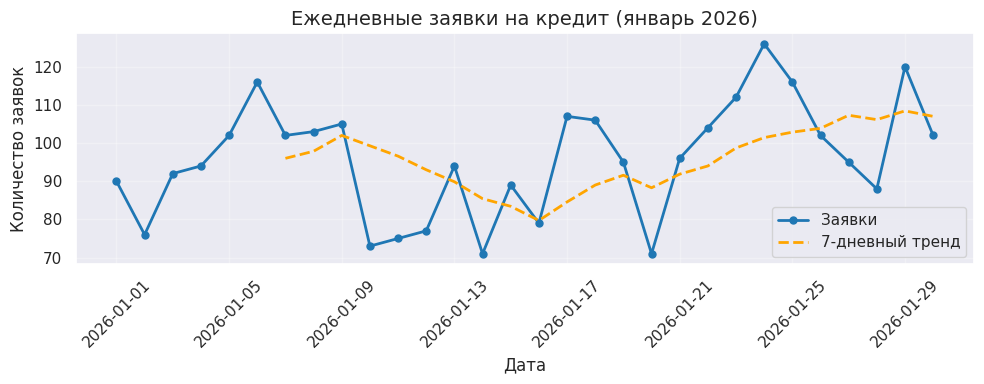

In [ ]:
# Создаём временной ряд: 30 дней, начиная с 1 января 2026
# pd.date_range — генерирует последовательность дат
# freq='D' означает "с шагом в 1 день"

dates = pd.date_range('2026-01-01', periods=30, freq='D')

# Генерируем 30 случайных чисел (среднее 100 заявок, разброс 15)
daily_apps = np.random.normal(100, 15, 30).astype(int)  # astype(int) превращает float в int


# plt.subplots() — создаёт "фигуру" (весь холст) и
# "оси" (координатную плоскость, на которой рисуем)
# figsize=(10,4) — ширина 10 дюймов, высота 4 дюйма

fig, ax = plt.subplots(figsize=(10, 4))

# ax.plot() — рисует линию
# Параметры:
#  - dates, daily_apps — координаты X и Y
#  - marker='o' — рисует кружочки в каждой точке
#  - linestyle='-' — сплошная линия
#   - color='#1f77b4' — цвет в HEX-формате (синий)
#   - linewidth=2 — толщина линии в пунктах
#  - markersize=5 — размер кружочков
#  - label='Заявки' — подпись для легенды


ax.plot(dates, daily_apps,
        marker='o',
        linestyle='-',
        color='#1f77b4',
        linewidth=2,
        markersize=5,
        label='Заявки')


# Добавляем скользящее среднее за 7 дней
# pd.Series(...).rolling(7).mean() — берёт каждые 7
# соседних значений и вычисляет среднее
# linestyle='--' — пунктирная линия

rolling = pd.Series(daily_apps).rolling(7).mean()
ax.plot(dates, rolling,
        linestyle='--',
        color='orange',
        linewidth=2,
        label='7-дневный тренд')

# Оформление: заголовок, подписи осей, легенда, сетка
# legend() показывает legend (подписи линий)
# tight_layout() убирает обрезание подписей

ax.set_title('Ежедневные заявки на кредит (январь 2026)', fontsize=14)
ax.set_xlabel('Дата')
ax.set_ylabel('Количество заявок')
ax.legend()
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)   # Поворачиваем даты, чтобы не накладывались
plt.tight_layout()
plt.show()

## Гистограмма — портрет типичного клиента

**Зачем нужна в банке:**
- Понять, какой доход у большинства заёмщиков
- Увидеть, есть ли несколько разных групп (например, наёмные работники и ИП)
- Найти нетипично высокие или низкие значения

**Как анализировать:**
- Форма: один горб — нормальное распределение; два горба — смесь двух групп; равномерное — все значения одинаково вероятны
- «Хвосты» — редкие, но важные клиенты

**Ошибка новичка:** использовать слишком мало или слишком много столбиков (`bins`). Хорошее правило — начать с 20–30 и подстраивать.

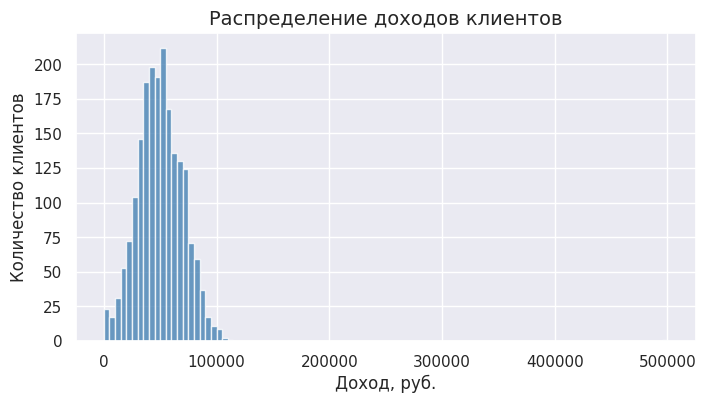

In [ ]:
# Показывает, как часто встречаются разные значения
# одного числового признака (например, доход)
# plt.subplots() — создаём фигуру и оси
# figsize=(8,4) — ширина 8 дюймов, высота 4 дюйма

fig, ax = plt.subplots(figsize=(8, 4))

# ax.hist() — строит гистограмму
# Параметры:
# - incomes — массив данных (колонка из DataFrame)
# - bins=100 — на сколько столбиков разбить диапазон
# - color='steelblue' — цвет столбиков
# - edgecolor='white' — цвет границ между столбиками
# - alpha=0.8 — прозрачность (1.0 — полностью непрозрач.)

ax.hist(df['income'],
        bins=100,
        color='steelblue',
        edgecolor='white',
        alpha=0.8)


# Оформление: заголовок, подписи осей

ax.set_title('Распределение доходов клиентов', fontsize=14)
ax.set_xlabel('Доход, руб.')
ax.set_ylabel('Количество клиентов')
plt.show()

**ИНТЕРПРЕТАЦИЯ:**
- Самый высокий столбик около 50 000 — это типичный доход нашего клиента.
- Справа есть небольшой «хвост» — богатые клиенты. Их мало, но они могут быть очень прибыльными.
- Один столбик далеко справа (около 500 000) — та самая аномалия, которую мы добавили. Это либо ошибка данных, либо действительно vip-клиент.

**Альтернатива — Seaborn (более стильно и автоматически подбирает bins):**

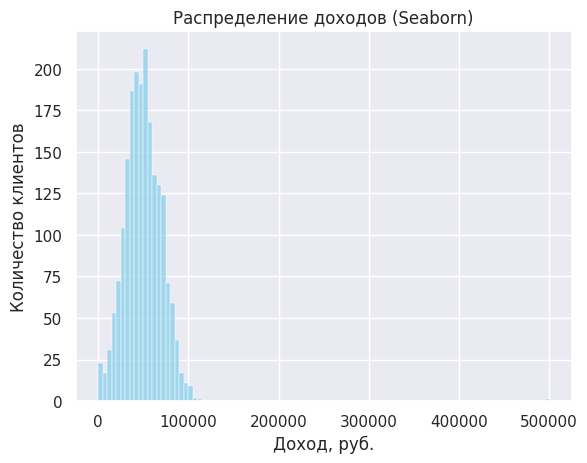

In [ ]:
# sns.histplot() — гистограмма от Seaborn
# Параметры те же, но стиль лучше


sns.histplot(df['income'], bins=100, color='skyblue', edgecolor='white')
plt.title('Распределение доходов (Seaborn)')
plt.xlabel('Доход, руб.')
plt.ylabel('Количество клиентов')
plt.show()

## Boxplot — ищем выбросы и сравниваем группы

**Зачем нужен в банке:**
- Обнаружение мошеннических транзакций (аномально большие суммы)
- Сравнение доходов по городам или филиалам
- Выявление ошибок в данных (возраст 150 лет, зарплата 0 рублей)

**Как читать boxplot (снизу вверх):**
- Нижний ус — минимальное «нормальное» значение
- Нижняя граница ящика — 25-й перцентиль (Q1)
- Линия внутри ящика — медиана (50-й перцентиль)
- Верхняя граница ящика — 75-й перцентиль (Q3)
- Верхний ус — максимальное «нормальное» значение (Q3 + 1.5 * IQR)
- Точки за усами — ВЫБРОСЫ. Именно они самые интересные!

**Ошибка новичка:** считать всё, что за усами, ошибкой и удалять. Так можно выплеснуть с водой и мошенников, и новых вип-клиентов. Выброс — это сигнал, а не приговор.

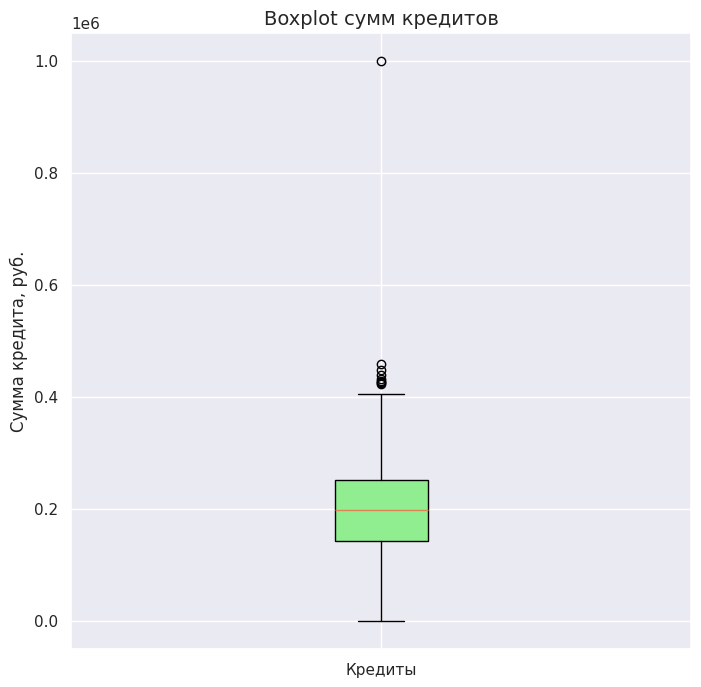

In [ ]:

#  BOXPLOT (ЯЩИК С УСАМИ)
# Показывает медиану, квартили и выбросы

fig, ax = plt.subplots(figsize=(8, 8))


# ax.boxplot() — строит ящик с усами.
# Параметры:
# - loan_amounts — массив данных (суммы кредитов)
# - vert=True — вертикальный boxplot
# - patch_artist=True — закрашиваем ящик цветом
# - boxprops=dict(facecolor='lightgreen') — цвет ящика

ax.boxplot(df['loan_amount'],
           vert=True,
           patch_artist=True,
           boxprops=dict(facecolor='lightgreen'))

ax.set_title('Boxplot сумм кредитов', fontsize=14)
ax.set_ylabel('Сумма кредита, руб.')
ax.set_xticklabels(['Кредиты'])
plt.show()

**ИНТЕРПРЕТАЦИЯ:**
- Зелёный ящик — это нормальный разброс сумм кредита (от Q1 до Q3).
- Медиана около 200 000 — половина кредитов меньше, половина больше.
- Верхний ус уходит к 400 000. Всё, что выше, — потенциальные аномалии (точки).
- Одна точка далеко сверху — кредит на 1 000 000 руб. Это тот самый добавленный нами выброс.

**Сравнение доходов по городам с помощью Seaborn (несколько ящиков рядом):**

/tmp/ipykernel_3069/717017792.py:6: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




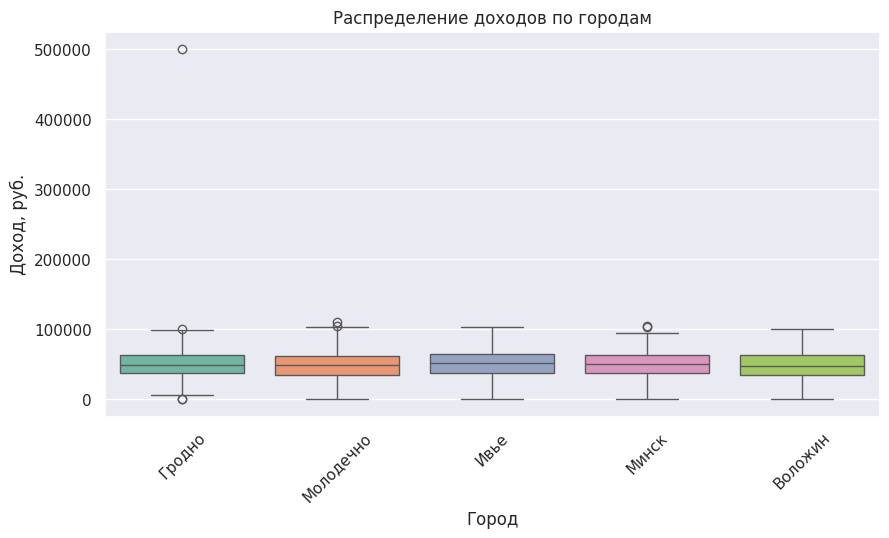

In [ ]:

# sns.boxplot() — несколько ящиков по категориям
# x='city' — по городам, y='income' — доход
# palette='Set2' — цветовая палитра.

plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='city', y='income', palette='Set2')
plt.title('Распределение доходов по городам')
plt.xlabel('Город')
plt.ylabel('Доход, руб.')
plt.xticks(rotation=45)
plt.show()

**ИНТЕРПРЕТАЦИЯ:**
- Медианный доход примерно одинаков во всех городах.
- Кружочки над ящиками — выбросы по доходам (особо богатые клиенты). Их можно передать в отдел продаж для особого обслуживания.

## Столбчатая диаграмма — сравнение категорий

**Зачем нужна в банке:**
- Сравнить средний доход, сумму кредита или уровень дефолта в разных городах
- Показать структуру портфеля (например, доля ипотечных vs потребительских кредитов)
- Визуализировать эффективность филиалов

**Как анализировать:**
- Сравниваем высоты столбцов
- Можно сортировать по убыванию для наглядности
- Горизонтальные bar chart хороши, когда много категорий

**Ошибка новичка:** забывать сортировать столбцы по убыванию — бар-чарт без сортировки теряет половину наглядности.

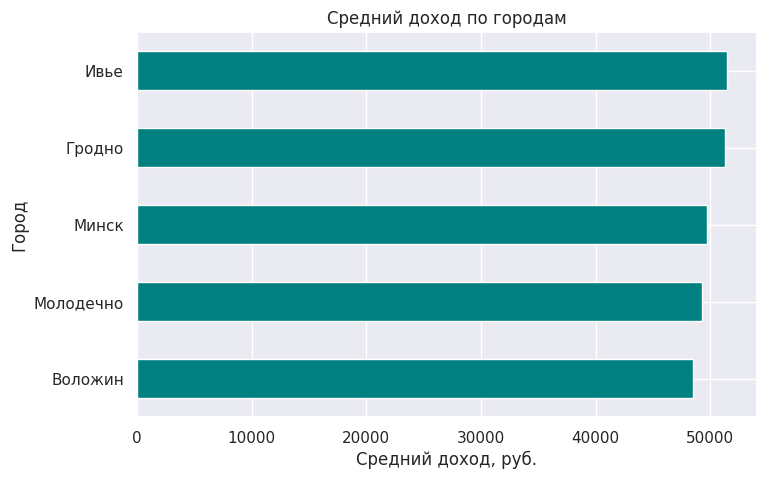

In [ ]:
# Показывает значения категорий
# Группируем по городам и считаем средний доход
# .groupby('city') — группировка по городам
#  ['income'].mean() — среднее значение дохода
#  .sort_values() — сортируем от маленького к большому
#  (для горизонтального barh это даст внизу наибольшее).

city_income = df.groupby('city')['income'].mean().sort_values()

fig, ax = plt.subplots(figsize=(8, 5))


#  .plot(kind='barh') — рисуем горизонтальную столбчатую  диаграмму
#  Параметры:
#   - ax=ax — на каких осях рисовать
#   - color='teal' — цвет столбцов
#  - edgecolor='white' — граница столбцов


city_income.plot(kind='barh', ax=ax, color='teal', edgecolor='white')
ax.set_title('Средний доход по городам')
ax.set_xlabel('Средний доход, руб.')
ax.set_ylabel('Город')
plt.show()

/tmp/ipykernel_3069/2880487158.py:9: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




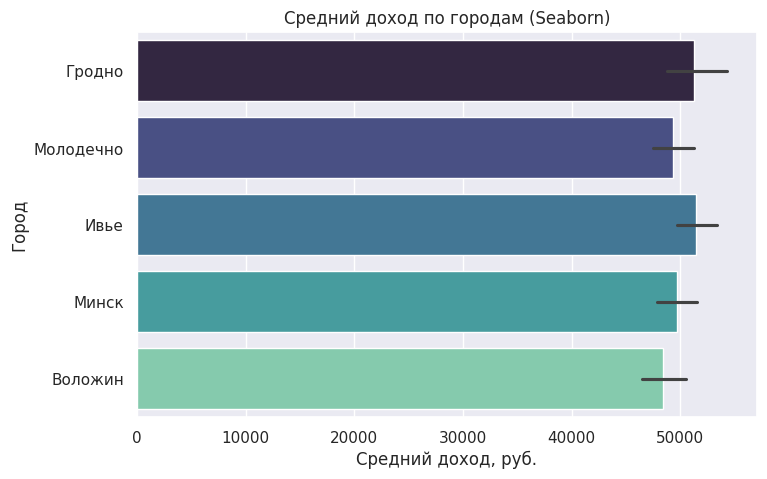

In [ ]:
# sns.barplot() — столбчатая диаграмма от Seaborn
# x='income' — что откладывать по оси X
# y='city' — категории по оси Y
# estimator=np.mean — какая статистика (среднее)
# palette='mako' — цветовая гамма


plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='income', y='city', estimator=np.mean, palette='mako')
plt.title('Средний доход по городам (Seaborn)')
plt.xlabel('Средний доход, руб.')
plt.ylabel('Город')
plt.show()

## Heatmap — корреляционная матрица

**Зачем нужна в банке:**
- Быстро найти признаки, которые сильно связаны друг с другом
- Понять, какие факторы влияют на дефолт заёмщика
- Увидеть мультиколлинеарность (когда два признака почти одинаковы)

**Как анализировать:**
- Значения от -1 до 1:
  - 1 — полная положительная связь (если один растёт, то и второй)
  - -1 — полная отрицательная связь (один растёт — второй падает)
  - 0 — никакой связи
- Ищем яркие клетки (тёмно-красные или тёмно-синие) — это сильные связи

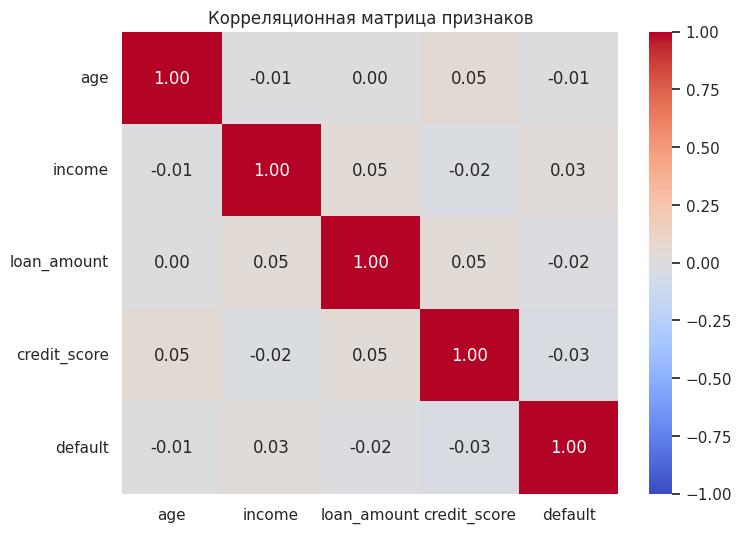

In [ ]:
# Показывает корреляции между всеми парами признаков


#   df[['col1','col2',...]].corr() — вычисляем корреляцию
#   (метод Пирсона по умолчанию)

corr = df[['age', 'income', 'loan_amount', 'credit_score', 'default']].corr()

plt.figure(figsize=(8, 6))


#   sns.heatmap() — рисуем тепловую карту
#  - corr — матрица корреляций
#   - annot=True — показывать числа внутри клеток
#  - cmap='coolwarm' — цветовая схема (холодный-горячий)
#  - vmin=-1, vmax=1 — диапазон значений
#   - fmt='.2f' — формат чисел (2 знака после запятой)

sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f')
plt.title('Корреляционная матрица признаков')
plt.show()

**ИНТЕРПРЕТАЦИЯ:**
- `loan_amount` и `income` имеют небольшую положительную корреляцию (число в клетке) — с ростом дохода люди берут чуть больше кредита.
- `credit_score` и `default` — отрицательная корреляция (чем выше скоринг, тем меньше вероятность дефолта). Это ожидаемо и хорошо.
- Если бы где-то стояло 0.9 — это опасный звоночек: признаки почти дублируют друг друга (мультиколлинеарность), модель может стать нестабильной.

## Pairplot — быстрый обзор всех связей

**Зачем нужен:**
- За пару секунд увидеть все попарные scatter plots и распределения
- Найти неожиданные закономерности
- Идеально для презентации «что вообще в данных»



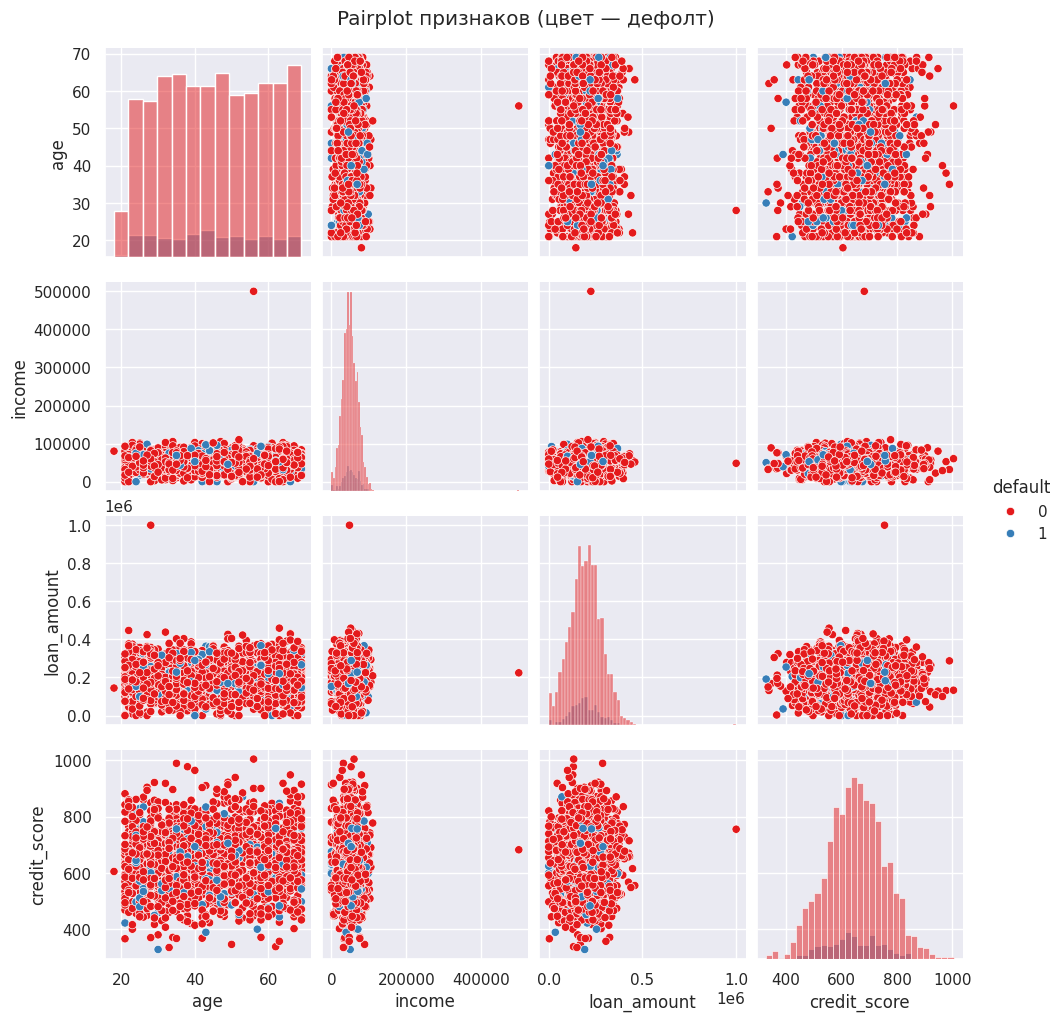

In [ ]:
# PAIRPLOT (ПАРНЫЕ ГРАФИКИ)
# Строит scatter plots для каждой пары числовых колонок
# и гистограммы на диагонали
#   sns.pairplot()
#   - первым аргументом — DataFrame
#   - vars — список колонок, которые хотим показать
#   - hue='default' — раскрашиваем точки по дефолту
#   - palette='Set1' — цветовая палитра
#   - diag_kind='hist' — на диагонали гистограммы
#   - height=2.5 — размер каждого графика

sns.pairplot(df,
             vars=['age', 'income', 'loan_amount', 'credit_score'],
             hue='default',
             palette='Set1',
             diag_kind='hist',
             height=2.5)
plt.suptitle('Pairplot признаков (цвет — дефолт)', y=1.02)
plt.show()

**ИНТЕРПРЕТАЦИЯ:**
- На диагонали — гистограммы для каждого признака отдельно для плательщиков и дефолтников.
- На пересечениях — scatter plots. Видно, что дефолтники (красные точки) чаще имеют низкий скоринг и низкий доход.
- Это мощный инструмент для быстрого поиска гипотез: если красные точки кучкуются в какой-то области, значит, там повышенный риск дефолта.

## Plotly Express — интерактивная визуализация

**Преимущества Plotly:**
- График можно вращать, приближать, наводить курсор для подсказок
- Экспорт в HTML, вставка в дашборды
- Отлично смотрится в презентациях и на сайтах

**Когда использовать:**
- Когда нужно показать данные руководству или клиенту
- Когда данных много и хочется дать возможность исследовать их самостоятельно
- Для создания дашбордов (Dash)

In [ ]:
# px.scatter() — интерактивный scatter plot от Plotly
# - df — DataFrame
#   - x, y — колонки для осей
#   - color='age' — цвет точек по возрасту
#   - size='credit_score' — размер точки по скорингу
#  - hover_name='client_id' — что показывать при наведении
#   - title — заголовок графика

fig = px.scatter(df, x='income', y='loan_amount', color='age',
                 size='credit_score', hover_name='client_id',
                 title='Интерактивный scatter plot (Plotly)',
                 labels={'income':'Доход, руб.', 'loan_amount':'Сумма кредита, руб.'})
fig.show()

In [ ]:
#   px.histogram() — интерактивная гистограмма
#   - nbins=30 — количество столбиков

fig = px.histogram(df, x='income', nbins=30, title='Интерактивная гистограмма доходов')
fig.show()

**ПОПРОБУЙ:**
- Наведи мышь на точку — увидишь ID клиента, доход, сумму кредита
- Выдели область — график увеличится
- Дважды кликни — сбросится масштаб
- В правом верхнем углу — кнопки для сохранения в PNG

## Твоя очередь!

Используя наш датасет `df`, построй следующие графики и сделай выводы:

1. **Boxplot** суммы кредита по городам — в каком городе самый большой разброс?
2. **Гистограмму** возраста клиентов — какой возраст наиболее типичен?
3. **Scatter plot** возраста и кредитного скоринга, раскрась по дефолту.
4. **Бар-чарт** количества клиентов по городам (посчитай через `value_counts()`).
5. **Любой интерактивный график Plotly** на твой выбор — покажи, что умеешь.

Для каждого графика напиши текстовую ячейку с выводами: какие закономерности ты видишь, есть ли аномалии, что бы ты порекомендовал бизнесу.



---

